# Attentional Spatial Bias: Analysis

Ported from `attentional_spatial_bias_colab.py`, which someone else wrote
and which hadn't been verified before this notebook. Checking its logic
against `data/raw/` turned up two real bugs, see the note before each fix.

**Data:** 12 subjects with the full 48-trial, 6-arrangement design:
8 LTR (43, 51, 101, 102, 104, 105, 106, 107) and 4 RTL (44, 52, 54, 103).
subject-1/3/50/83 are older pilot runs with an incompatible position
scheme, so they're left out.

**Caveat:** subjects 43 and 44 were recorded before the experiment
script's "FIX (V8)" HiDPI fix, so their online-logged `first_fix_side` is
unusable (see Section 6). Their FPOG-recomputed values are fine and a
sensitivity check excluding them barely moves the group estimates.

## 1. Setup

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data location

Restricted to the 12 subjects with the full 48-trial, 6-arrangement design.

In [2]:
DATA_DIR = "../data/raw"
SUBJECTS = ["subject-43", "subject-44", "subject-51", "subject-52", "subject-54", "subject-101", "subject-102", "subject-103", "subject-104", "subject-105", "subject-106", "subject-107"]
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

for s in SUBJECTS:
    for ext in (".csv", ".tsv"):
        p = os.path.join(DATA_DIR, s + ext)
        assert os.path.exists(p), f"missing {p}"
print("Data files found for:", SUBJECTS)

Data files found for: ['subject-43', 'subject-44', 'subject-51', 'subject-52', 'subject-54', 'subject-101', 'subject-102', 'subject-103', 'subject-104', 'subject-105', 'subject-106', 'subject-107']


## 3. Config: arrangement / clock mapping

**Bug 1:** the original code derived clock hour from pixel offsets with
`atan2(y, x)`, which assumes math convention (y up). The logged offsets
are actually screen convention (y down), confirmed against
`scripts/data_evaluation.ipynb` and against real scanpaths. Feeding y-down
data into a y-up formula mirrors every non-horizontal arrangement
top-to-bottom: position `4` is really `(12, 6)`, not `(6, 12)` like the
original code had it, and 2/3/5/6 are off the same way. Fixed by computing
the clock hour straight from the pixel offsets instead of a hand-written
lookup table, so there's nothing left to drift out of sync.

**Design issue, not a bug:** the six arrangements are the six diameters of
a clock face. `img_left`/`img_right` always means "7 to 12 o'clock side"
vs "1 to 6 o'clock side," not screen left/right. For arrangement `(12, 6)`
both images sit on the vertical meridian, so calling `img_right` "the right
stimulus" there is really "the bottom stimulus." Fixed by recording the
actual fixated clock hour (Section 4) and deriving left/right and up/down
from it afterward (Section 8), each skipping the arrangement where that
axis doesn't apply.

In [3]:
POSITION_LABELS = {
    "1": (9, 3), "2": (10, 4), "3": (11, 5),
    "4": (12, 6), "5": (7, 1), "6": (8, 2),
}
ARRANGEMENT_ORDER = [(7, 1), (8, 2), (9, 3), (10, 4), (11, 5), (12, 6)]
CLOCK_ORDER = list(range(1, 13))

MIN_LATENCY_MS = 80   # saccades planned before stimulus onset land faster than this
WINSOR_PROP = 0.2
N_BOOT = 5000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


def clock_hour_from_xy(x, y):
    # clock hour for a point at screen offset (x, y) from center, y-down
    angle = math.degrees(math.atan2(y, x))
    h = (round(angle / 30.0) + 3) % 12
    return 12 if h == 0 else h


def clock_for_side(arrangement, side):
    return arrangement[0] if side == "left" else arrangement[1]


def hour_side(hour):
    # physical screen left/right of a clock hour; 6 and 12 sit on the
    # vertical meridian (x=0) and have no left/right meaning
    if pd.isna(hour):
        return np.nan
    if hour in (6, 12):
        return np.nan
    return "left" if hour in (7, 8, 9, 10, 11) else "right"


def hour_vert(hour):
    # physical screen up/down of a clock hour; 3 and 9 sit on the
    # horizontal meridian (y=0) and have no up/down meaning
    if pd.isna(hour):
        return np.nan
    if hour in (3, 9):
        return np.nan
    return "up" if hour in (10, 11, 12, 1, 2) else "down"

In [4]:
# Sanity-check POSITION_LABELS against the actual logged pixel offsets
seen = {}
for s in SUBJECTS:
    df = pd.read_csv(os.path.join(DATA_DIR, s + ".csv"), dtype=str)
    for _, row in df.iterrows():
        pos = row["position"]
        if pos not in seen:
            seen[pos] = (float(row["x_left"]), float(row["y_left"]),
                         float(row["x_right"]), float(row["y_right"]))

print(f"{'position':>8} {'computed':>10} {'expected':>10}  status")
for pos in sorted(seen, key=int):
    xl, yl, xr, yr = seen[pos]
    computed = (clock_hour_from_xy(xl, yl), clock_hour_from_xy(xr, yr))
    expected = POSITION_LABELS[pos]
    status = "OK" if computed == expected else "MISMATCH"
    print(f"{pos:>8} {str(computed):>10} {str(expected):>10}  {status}")

position   computed   expected  status
       1     (9, 3)     (9, 3)  OK
       2    (10, 4)    (10, 4)  OK
       3    (11, 5)    (11, 5)  OK
       4    (12, 6)    (12, 6)  OK
       5     (7, 1)     (7, 1)  OK
       6     (8, 2)     (8, 2)  OK


## 4. Load + tidy the subject CSVs

`block_index` is what filters out the pilot files. It's required here and
missing there, since their `position` codes mean something different
anyway.

`fix_direction()` also accepts a literal `"LEFT"`/`"RIGHT"`/`"none"`
encoding seen in one of the pilot files, even though the current subjects
only use the filename form.

In [5]:
def load_subject_csv(path):
    df = pd.read_csv(path, dtype=str)
    keep_cols = [
        "subject_nr", "group", "lang", "trial_nr", "block_index",
        "position", "img_left", "img_right",
        "x_left", "y_left", "x_right", "y_right",
        "first_fix_side", "first_fix_rt", "response_time", "correct",
    ]
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path}: missing expected columns {missing}")
    df = df[keep_cols].copy()

    df["trial_nr"] = df["trial_nr"].astype(int)
    df["block_index"] = df["block_index"].astype(int)
    for c in ["first_fix_rt", "response_time", "x_left", "y_left", "x_right", "y_right"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["arrangement"] = df["position"].map(POSITION_LABELS)
    if df["arrangement"].isna().any():
        bad = df.loc[df["arrangement"].isna(), "position"].unique()
        raise ValueError(f"{path}: unmapped position code(s) {bad} -- update POSITION_LABELS")

    def fix_direction(row):
        side = row["first_fix_side"]
        if pd.isna(side) or side == "none":
            return "none"
        if side == row["img_left"]:
            return "left"
        if side == row["img_right"]:
            return "right"
        su = str(side).strip().upper()
        if su in ("LEFT", "RIGHT"):
            return su.lower()
        return "none"

    df["first_fix_direction"] = df.apply(fix_direction, axis=1)
    # NOTE: these three are derived from the buggy CSV-log `first_fix_side`
    # (see Section 6/7 -- unusable for subjects 43/44). Named with a
    # `csvlog_` prefix so nothing downstream mistakes them for the
    # FPOG-based (correct) versions computed in Section 7.
    df["csvlog_fixated_clock"] = df.apply(
        lambda r: clock_for_side(r["arrangement"], r["first_fix_direction"])
        if r["first_fix_direction"] != "none" else np.nan, axis=1)
    df["csvlog_physical_side"] = df["csvlog_fixated_clock"].map(hour_side)
    df["csvlog_physical_vert"] = df["csvlog_fixated_clock"].map(hour_vert)

    reading_start_side = {"LTR": "left", "RTL": "right"}
    df["reading_start_side"] = df["group"].map(reading_start_side)
    df["fix_matches_reading_onset"] = (
        df["first_fix_direction"] == df["reading_start_side"]
    ).where(df["first_fix_direction"] != "none")

    df.rename(columns={"first_fix_rt": "first_fix_rt_ms",
                        "response_time": "response_time_ms"}, inplace=True)
    df["subject_nr"] = df["subject_nr"].astype(str)
    return df


def apply_exclusions(df, side_col="first_fix_direction", rt_col="first_fix_rt_ms",
                      rt_cutoff_ms=None, min_latency_ms=None,
                      reason_col="exclusion_reason", excluded_col="excluded"):
    # rt_cutoff_ms=None means no upper latency cutoff, the current default:
    # slow first fixations cluster in arrangements without an upper-left
    # stimulus, so cutting them would be behaviorally selective (see the
    # latency-by-arrangement section). min_latency_ms=None keeps the original
    # script's behaviour (no lower bound); the FPOG-based pass sets it to
    # MIN_LATENCY_MS to drop anticipatory first fixations.
    df = df.copy()
    df[reason_col] = "none"
    no_fix = df[side_col] == "none"
    df.loc[no_fix, reason_col] = "no_first_fixation_registered"
    if rt_cutoff_ms is not None:
        too_slow = (~no_fix) & (df[rt_col] > rt_cutoff_ms)
        df.loc[too_slow, reason_col] = "first_fix_rt_over_cutoff"
    if min_latency_ms is not None:
        too_fast = (~no_fix) & (df[rt_col] < min_latency_ms)
        df.loc[too_fast, reason_col] = "first_fix_anticipatory"
    df[excluded_col] = df[reason_col] != "none"
    return df


paths = [os.path.join(DATA_DIR, s + ".csv") for s in SUBJECTS]
frames = [load_subject_csv(p) for p in paths]
trials = pd.concat(frames, ignore_index=True)
# Not exported yet -- the FPOG-based columns (Sections 6-7) still need to be
# merged in before `trials_combined.csv` is written (see Section 7).

n_subj = trials["subject_nr"].nunique()
print(f"Loaded {len(paths)} file(s), {n_subj} subject(s), {len(trials)} trials.")

Loaded 12 file(s), 12 subject(s), 576 trials.


## 5. Bootstrap helpers

`hierarchical_bootstrap_ci` resamples subjects first, then trials within
each resampled subject, since trials from the same subject aren't
independent. Point estimate is the mean of subject means. This shouldn't
need any changes once more subjects are added.

In [6]:
def hierarchical_bootstrap_ci(arrays, n_boot=N_BOOT):
    # arrays: one 0/1 (or numeric) array per subject.
    # Stage 1 resamples subjects, stage 2 resamples trials within each
    # sampled subject. Point estimate = unweighted mean of subject means.
    arrays = [np.asarray(a, dtype=float) for a in arrays if len(a) > 0]
    k = len(arrays)
    if k == 0:
        return np.nan, np.nan, np.nan
    point = float(np.mean([a.mean() for a in arrays]))
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, k, k) if k > 1 else np.zeros(1, dtype=int)
        boots[i] = np.mean([arrays[j][rng.integers(0, len(arrays[j]), len(arrays[j]))].mean()
                            for j in idx])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


colors = {"LTR": "#1f77b4", "RTL": "#d62728"}

## 6. Verifying `first_fix_side` against the raw eye-tracker samples

`first_fix_side` isn't a raw measurement. It's a value the OpenSesame
script computed live and logged. This section recomputes it independently
from the tracker's own fixation stream.

`FPOGX`/`FPOGY` are GazePoint's fixation-classified gaze coordinates
(grouped by `FPOGID`, with `FPOGS`/`FPOGD` for start time and duration),
not raw per-sample gaze. The `.tsv` also has `STIMULUS_ONSET`/`IMAGE_OFFSET`
markers to segment trials.

For each trial: take the fixations inside that window, in time order, and
find the first one landing inside either stimulus's AOI. That's a square,
half-width 150 px, matching the margin the experiment itself uses online
(stimuli are about 256x256 px on screen, centers 616 px apart, so the two
AOIs never overlap). Fixations already running at stimulus onset get
dropped, since they belong to the preceding central fixation dot rather
than the stimuli. Only fixations starting at or after onset count.

In [7]:
SCREEN_W, SCREEN_H = 1920, 1080
# Square AOI half-width around each stimulus center, taken from the
# experiment script's own online detection (margin = 150 in
# V7_AttentionalSpatialBias_.osexp). Stimuli are ~256x256 px on screen
# (1025x1025 png at scale=0.25), so this is half-size 128 px + ~22 px slack.
AOI_MARGIN_PX = 150


def compute_fpog_first_fixation(subj, sub_trials):
    # sub_trials: this subject's rows from `trials` (already parsed by
    # load_subject_csv), used for the per-trial stimulus coordinates --
    # avoids re-reading and re-parsing the CSV with separate logic.
    tsv_path = os.path.join(DATA_DIR, subj + ".tsv")

    tsv = pd.read_csv(tsv_path, sep="\t")
    tsv.replace(["NA", "undefined"], np.nan, inplace=True)
    for c in ["TIME", "FPOGX", "FPOGY", "FPOGV", "FPOGID", "FPOGS"]:
        tsv[c] = pd.to_numeric(tsv[c], errors="coerce")
    tsv = tsv.dropna(subset=["FPOGX", "FPOGY", "FPOGID"]).sort_values("TIME").reset_index(drop=True)

    onsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("STIMULUS_ONSET", na=False)].copy()
    offsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("IMAGE_OFFSET", na=False)]["TIME"].values

    sub_trials = sub_trials.sort_values("trial_nr").reset_index(drop=True)
    if len(onsets) != len(sub_trials):
        raise ValueError(f"{subj}: {len(onsets)} STIMULUS_ONSET markers vs {len(sub_trials)} trial rows")

    rows = []
    for (_, onset_row), (_, trial) in zip(onsets.iterrows(), sub_trials.iterrows()):
        t0 = onset_row["TIME"]
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        window = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t_end) & (tsv["FPOGV"] == 1) &
                     tsv["FPOGX"].between(0, 1) & tsv["FPOGY"].between(0, 1)]

        fixations = (window.groupby("FPOGID")
                     .agg(dx=("FPOGX", "mean"), dy=("FPOGY", "mean"), FPOGS=("FPOGS", "min"))
                     .sort_values("FPOGS"))
        # the fixation in progress at stimulus onset is the tail of the
        # central-dot fixation, not a response to the stimuli -- drop it
        fixations = fixations[fixations["FPOGS"] >= t0]

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        side, rt_ms = "none", np.nan
        for _, fx in fixations.iterrows():
            xi, yi = fx["dx"] * SCREEN_W, fx["dy"] * SCREEN_H
            in_left = abs(xi - lx) < AOI_MARGIN_PX and abs(yi - ly) < AOI_MARGIN_PX
            in_right = abs(xi - rx) < AOI_MARGIN_PX and abs(yi - ry) < AOI_MARGIN_PX
            if in_left or in_right:  # AOIs are 616 px apart, never both
                side = "left" if in_left else "right"
                rt_ms = (fx["FPOGS"] - t0) * 1000.0  # s -> ms, same units as first_fix_rt
                break

        rows.append(dict(subject_nr=str(trial["subject_nr"]), trial_nr=int(trial["trial_nr"]),
                          fpog_first_fix_direction=side, fpog_first_fix_rt_ms=rt_ms))
    return pd.DataFrame(rows)


subj_id = {s: s.split("-")[1] for s in SUBJECTS}  # "subject-43" -> "43"
fpog_frames = [compute_fpog_first_fixation(s, trials[trials["subject_nr"] == subj_id[s]])
               for s in SUBJECTS]
fpog_df = pd.concat(fpog_frames, ignore_index=True)

# drop any fpog_* columns from a previous run of this cell, so re-running it
# doesn't create _x/_y merge collisions
trials = trials.drop(columns=[c for c in trials.columns if c.startswith("fpog_")])
trials = trials.merge(fpog_df, on=["subject_nr", "trial_nr"], validate="one_to_one")
# Still not exported -- Section 7 adds the FPOG-based exclusion flags and
# fixated_clock/physical_side/physical_vert columns, then writes
# `trials_combined.csv` once, with everything in it.

print("=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===")
print(pd.crosstab(trials["first_fix_direction"], trials["fpog_first_fix_direction"],
                   rownames=["CSV first_fix_side"], colnames=["FPOG-recomputed"]))
agree = (trials["first_fix_direction"] == trials["fpog_first_fix_direction"]).mean()
print(f"\nAgreement: {agree:.1%}")
print("\nCSV first_fix_side value counts:", trials["first_fix_direction"].value_counts().to_dict())
print("FPOG-recomputed value counts:   ", trials["fpog_first_fix_direction"].value_counts().to_dict())

=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===
FPOG-recomputed     left  none  right
CSV first_fix_side                   
left                 322     0     20
none                  18     4     12
right                 30     4    166

Agreement: 85.4%

CSV first_fix_side value counts: {'left': 342, 'right': 200, 'none': 34}
FPOG-recomputed value counts:    {'left': 370, 'right': 198, 'none': 8}


For subjects 43/44, `first_fix_side` never reports a rightward fixation
(0/96 trials), while the FPOG recomputation finds plenty in both. That's
not noise, it's a systematic left/none bias. The experiment script has a
fix for exactly this failure mode ("FIX (V8): use var.width/var.height, not
win.size," a HiDPI coordinate bug), so 43/44 were most likely recorded
before that fix went in and 51 after. From here on the notebook uses the
FPOG-recomputed values.

## 7. Exclusions on the FPOG-recomputed first fixation

Only two exclusions: trials with no FPOG-detected AOI fixation, and
anticipatory first fixations (latency < 80 ms, planned before stimulus
onset). There is no upper latency cutoff: slow first fixations aren't
random, they cluster in arrangements that offer no upper-left stimulus
(see the latency-by-arrangement section below), so cutting them would be
behaviorally selective. The group bias estimates barely change either way.
Produces `df_valid_fpog`, used for everything from here on.

This cell also writes `results/trials_combined.csv`, the one export of the
full per-trial table. It contains **both** versions of
fixated_clock/physical_side/physical_vert, prefixed so their provenance is
unambiguous:

- **`fpog_fixated_clock` / `fpog_physical_side` / `fpog_physical_vert`** --
  recomputed offline from the tracker's fixation stream (Section 6), with
  the Section 7 exclusions applied (`NaN` for excluded trials or trials with
  no FPOG-detected fixation). **Use these.** They're what every analysis
  from here on in this notebook uses.
- `csvlog_fixated_clock` / `csvlog_physical_side` / `csvlog_physical_vert`
  -- derived from the online-logged `first_fix_side`, which is known to be
  buggy for subjects 43/44 (Section 6: 0/96 rightward fixations logged,
  not real behavior). Kept only so the CSV-log-vs-FPOG comparison in
  Section 6 is reproducible from the exported file; don't use these for
  any actual analysis.

In [8]:
trials = apply_exclusions(trials, side_col="fpog_first_fix_direction",
                           rt_col="fpog_first_fix_rt_ms",
                           min_latency_ms=MIN_LATENCY_MS,
                           reason_col="fpog_exclusion_reason", excluded_col="fpog_excluded")

n_excl_fpog = trials["fpog_excluded"].sum()
print(f"FPOG-based: excluded {n_excl_fpog}/{len(trials)} trials "
      f"({n_excl_fpog/len(trials):.1%}).")
print("\nExclusion breakdown:")
print(trials["fpog_exclusion_reason"].value_counts().to_string())
print(f"\n(no AOI fixation / latency < {MIN_LATENCY_MS} ms anticipatory; "
      f"no upper latency cutoff, slow first fixations are analyzed below)")

# FPOG-based fixated_clock/physical_side/physical_vert, computed for every
# trial (not just the surviving ones) so they can be exported alongside the
# CSV-log versions below -- NaN wherever fpog_excluded is True or
# fpog_first_fix_direction is "none", exactly like df_valid_fpog gets it.
trials["fpog_fixated_clock"] = trials.apply(
    lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"])
    if (not r["fpog_excluded"]) and r["fpog_first_fix_direction"] != "none" else np.nan, axis=1)
trials["fpog_physical_side"] = trials["fpog_fixated_clock"].map(hour_side)
trials["fpog_physical_vert"] = trials["fpog_fixated_clock"].map(hour_vert)

df_valid_fpog = trials[~trials["fpog_excluded"]].copy()

df_valid_fpog["fixated_clock"] = df_valid_fpog.apply(
    lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"])
    if r["fpog_first_fix_direction"] != "none" else np.nan, axis=1)
df_valid_fpog["physical_side"] = df_valid_fpog["fixated_clock"].map(hour_side)
df_valid_fpog["physical_vert"] = df_valid_fpog["fixated_clock"].map(hour_vert)

# Now export the combined per-trial table. Both versions of
# fixated_clock/physical_side/physical_vert are included, clearly labelled:
# `fpog_*` (recomputed offline from the tracker's fixation stream -- correct,
# used for every analysis in Sections 7 onward) and `csvlog_*` (derived from
# the online-logged, buggy `first_fix_side` -- kept only for comparison, see
# Section 6). Anyone reusing this CSV should use the `fpog_*` columns.
trials.to_csv(os.path.join(OUT_DIR, "trials_combined.csv"), index=False)

FPOG-based: excluded 16/576 trials (2.8%).

Exclusion breakdown:
fpog_exclusion_reason
none                            560
no_first_fixation_registered      8
first_fix_anticipatory            8

(no AOI fixation / latency < 80 ms anticipatory; no upper latency cutoff, slow first fixations are analyzed below)


## 8. Orientation-decomposed bias: left/right vs up/down

`img_left`/`img_right` is a 7-12 vs 1-6 o'clock split, not a screen
left/right split, and arrangement `(12, 6)` has no horizontal component at
all. So instead of one `mean_p_right` number, `fixated_clock` gets split
into two contrasts:

- left/right: skips arrangement `(12, 6)` (hours 6/12 sit on the vertical
  meridian)
- up/down: skips arrangement `(9, 3)` (hours 3/9 sit on the horizontal
  meridian)

LTR and RTL trials are pooled within each group so both sit side by side on
one plot.

Group CIs use the hierarchical bootstrap from Section 5, since trials from
the same subject aren't independent. The dots on each bar are individual
subject means, worth checking whether subjects actually agree, especially
with this few. Also worth noting: `P(down) = 1 − P(up)` and
`P(left) = 1 − P(right)` by construction, so the four bars are really two
numbers shown twice. The clock-face plot below has the full 12-direction
version.

=== P(first fixation in each direction), by group (FPOG-based) ===
(bar = mean of subject means; CI = hierarchical bootstrap)
group direction  n_subjects  n_trials        p    ci_lo    ci_hi
  LTR     right           8       310 0.373684 0.275000 0.474698
  LTR      left           8       310 0.626316 0.525302 0.725000
  RTL     right           4       157 0.361824 0.256250 0.487500
  RTL      left           4       157 0.638176 0.512500 0.743750
  LTR        up           8       311 0.600689 0.393737 0.776324
  LTR      down           8       311 0.399311 0.223676 0.606263
  RTL        up           4       156 0.838889 0.774306 0.900000
  RTL      down           4       156 0.161111 0.100000 0.225694


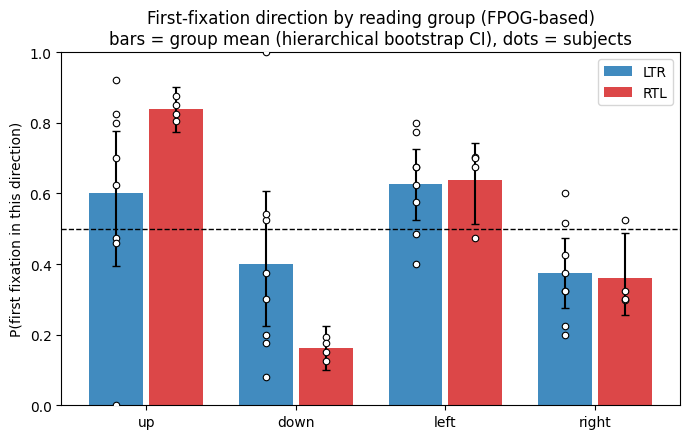

In [9]:
def pooled_orientation_table(df, axis_col, positive_label, negative_label):
    rows, subj_rows = [], []
    for group, g in df.dropna(subset=[axis_col]).groupby("group"):
        per_subj = [(subj, (sg[axis_col] == positive_label).astype(float).values)
                    for subj, sg in g.groupby("subject_nr")]
        arrays = [a for _, a in per_subj]
        p_pos, lo_pos, hi_pos = hierarchical_bootstrap_ci(arrays)
        rows.append(dict(group=group, direction=positive_label, n_subjects=len(arrays),
                          n_trials=len(g), p=p_pos, ci_lo=lo_pos, ci_hi=hi_pos))
        rows.append(dict(group=group, direction=negative_label, n_subjects=len(arrays),
                          n_trials=len(g), p=1 - p_pos, ci_lo=1 - hi_pos, ci_hi=1 - lo_pos))
        for subj, a in per_subj:
            m = a.mean()
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=positive_label, p=m))
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=negative_label, p=1 - m))
    return pd.DataFrame(rows), pd.DataFrame(subj_rows)


group_lr, subj_lr = pooled_orientation_table(df_valid_fpog, "physical_side", "right", "left")
group_ud, subj_ud = pooled_orientation_table(df_valid_fpog, "physical_vert", "up", "down")
group_dir = pd.concat([group_lr, group_ud], ignore_index=True)
subj_dir = pd.concat([subj_lr, subj_ud], ignore_index=True)
group_dir.to_csv(os.path.join(OUT_DIR, "group_orientation_bias_fpog.csv"), index=False)

print("=== P(first fixation in each direction), by group (FPOG-based) ===")
print("(bar = mean of subject means; CI = hierarchical bootstrap)")
print(group_dir.to_string(index=False))

direction_order = ["up", "down", "left", "right"]
groups_present = sorted(group_dir["group"].unique())
fig, ax = plt.subplots(figsize=(7, 4.5))
n_groups = len(groups_present)
width = 0.8 / n_groups
x = np.arange(len(direction_order))
for gi, group in enumerate(groups_present):
    sub = group_dir[group_dir["group"] == group].set_index("direction").reindex(direction_order)
    xpos = x + (gi - (n_groups - 1) / 2) * width
    lo = (sub["p"] - sub["ci_lo"]).values
    hi = (sub["ci_hi"] - sub["p"]).values
    ax.bar(xpos, sub["p"], width=width * 0.9, color=colors.get(group, "gray"),
           label=group, yerr=[lo, hi], capsize=3, alpha=0.85)
    ssub = subj_dir[subj_dir["group"] == group]
    for di, direction in enumerate(direction_order):
        pts = ssub.loc[ssub["direction"] == direction, "p"]
        ax.scatter(np.full(len(pts), xpos[di]), pts, s=22, zorder=3,
                   facecolor="white", edgecolor="black", linewidth=0.8)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(direction_order)
ax.set_ylim(0, 1)
ax.set_ylabel("P(first fixation in this direction)")
ax.set_title("First-fixation direction by reading group (FPOG-based)\n"
             "bars = group mean (hierarchical bootstrap CI), dots = subjects")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "group_orientation_bias_fpog.png"), dpi=150)
plt.show()

### Clock-face view: P(first fixation) per clock hour

The stimuli sit on a circle, so this just plots the bias on one: for each
clock hour, the share of trials where it was presented and fixated first.
Chance is 0.5 (dashed circle). Each hour has at most 8 trials per subject,
so the thin lines (individual subjects) are noisy. Thick lines are group
means. Opposite hours mirror each other, same as the bars above.

=== P(first fixation on hour h | h presented), by group ===
group    LTR    RTL
hour               
1      0.627  0.710
2      0.359  0.705
3      0.266  0.188
4      0.382  0.165
5      0.286  0.062
6      0.312  0.000
7      0.373  0.290
8      0.641  0.295
9      0.734  0.812
10     0.618  0.835
11     0.714  0.938
12     0.688  1.000


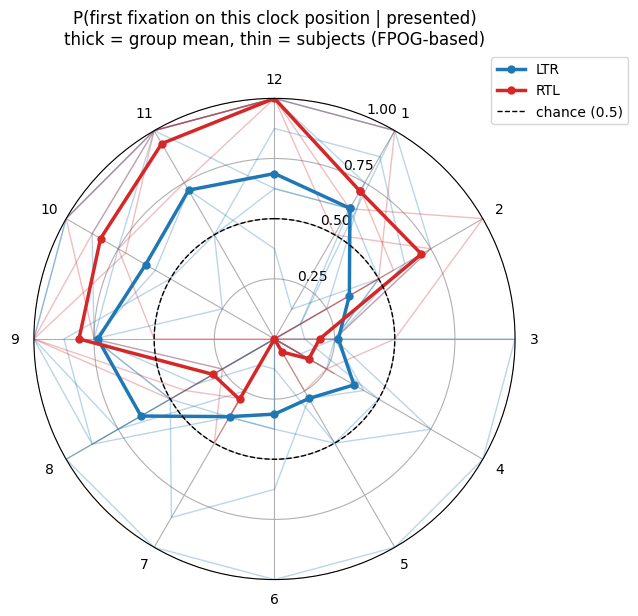

In [10]:
rows = []
for _, r in df_valid_fpog.dropna(subset=["fixated_clock"]).iterrows():
    for h in r["arrangement"]:
        rows.append(dict(group=r["group"], subject_nr=r["subject_nr"], hour=int(h),
                          fixated=float(r["fixated_clock"] == h)))
clock_long = pd.DataFrame(rows)

subj_clock = (clock_long.groupby(["group", "subject_nr", "hour"])["fixated"]
              .agg(["mean", "count"]).reset_index())
group_clock = (subj_clock.groupby(["group", "hour"])["mean"]
               .mean().reset_index(name="p"))  # mean of subject means
group_clock.to_csv(os.path.join(OUT_DIR, "clock_face_bias_fpog.csv"), index=False)

print("=== P(first fixation on hour h | h presented), by group ===")
print(group_clock.pivot(index="hour", columns="group", values="p").round(3).to_string())


fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(projection="polar"))
ax.set_theta_zero_location("N")   # 12 o'clock at top
ax.set_theta_direction(-1)        # hours increase clockwise
hours = CLOCK_ORDER
theta = [h * np.pi / 6 for h in hours]
theta_closed = theta + [theta[0]]

# NaN (an hour with no surviving trials, e.g. all excluded) leaves a gap in
# that group's line rather than being silently interpolated
for (group, subj), g in subj_clock.groupby(["group", "subject_nr"]):
    vals = g.set_index("hour")["mean"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            alpha=0.3, linewidth=1)
for group, g in group_clock.groupby("group"):
    vals = g.set_index("hour")["p"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            linewidth=2.5, marker="o", markersize=5, label=group)

circle_theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(circle_theta, np.full_like(circle_theta, 0.5), "--", color="black",
        linewidth=1, label="chance (0.5)")

ax.set_xticks(theta)
ax.set_xticklabels([str(h) for h in hours])
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title("P(first fixation on this clock position | presented)\n"
             "thick = group mean, thin = subjects (FPOG-based)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "clock_face_bias_fpog.png"), dpi=150)
plt.show()

### Quadrant view: each subject as one 2-D bias vector

Same left/right and up/down contrasts as above, plotted as one point per
subject instead of two bar charts:

- x = P(right) − P(left) (arrangement `(12, 6)` excluded)
- y = P(up) − P(down) (arrangement `(9, 3)` excluded)

Both run from −1 to +1, 0 = no bias. The quadrant a point falls in shows the
direction of that subject's bias at a glance.

=== Per-subject and group-mean bias vectors (FPOG-based) ===
group subject_nr         x         y  n_side  n_vert   x_ci_lo   x_ci_hi   y_ci_lo  y_ci_hi
  LTR        101 -0.250000 -0.050000    40.0    40.0       NaN       NaN       NaN      NaN
  LTR        102 -0.350000  0.400000    40.0    40.0       NaN       NaN       NaN      NaN
  LTR        104 -0.150000  0.842105    40.0    38.0       NaN       NaN       NaN      NaN
  LTR        105 -0.550000  0.650000    40.0    40.0       NaN       NaN       NaN      NaN
  LTR        106 -0.351351 -0.081081    37.0    37.0       NaN       NaN       NaN      NaN
  LTR        107  0.030303 -1.000000    33.0    36.0       NaN       NaN       NaN      NaN
  LTR         43 -0.600000  0.600000    40.0    40.0       NaN       NaN       NaN      NaN
  LTR         51  0.200000  0.250000    40.0    40.0       NaN       NaN       NaN      NaN
  RTL        103 -0.405405  0.611111    37.0    36.0       NaN       NaN       NaN      NaN
  RTL         44 -0

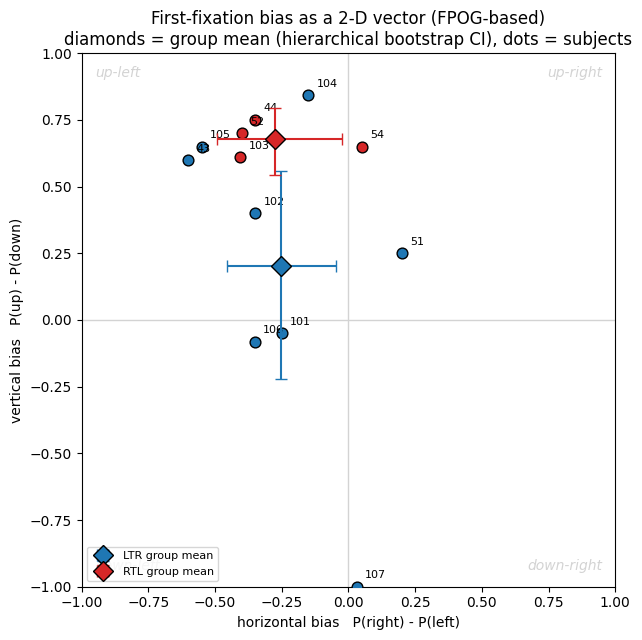

In [11]:
subj_rows = []
for (group, subj), g in df_valid_fpog.groupby(["group", "subject_nr"]):
    side = g["physical_side"].dropna()
    vert = g["physical_vert"].dropna()
    px = (side == "right").astype(float).values
    py = (vert == "up").astype(float).values
    subj_rows.append(dict(group=group, subject_nr=subj,
                           x=2 * px.mean() - 1, y=2 * py.mean() - 1,
                           n_side=len(px), n_vert=len(py)))
quad_subj = pd.DataFrame(subj_rows)

group_rows = []
for group, g in df_valid_fpog.groupby("group"):
    side_arrays = [(sg["physical_side"].dropna() == "right").astype(float).values
                   for _, sg in g.groupby("subject_nr")]
    vert_arrays = [(sg["physical_vert"].dropna() == "up").astype(float).values
                   for _, sg in g.groupby("subject_nr")]
    px, px_lo, px_hi = hierarchical_bootstrap_ci(side_arrays)
    py, py_lo, py_hi = hierarchical_bootstrap_ci(vert_arrays)
    group_rows.append(dict(group=group, subject_nr="GROUP_MEAN",
                            x=2 * px - 1, y=2 * py - 1,
                            x_ci_lo=2 * px_lo - 1, x_ci_hi=2 * px_hi - 1,
                            y_ci_lo=2 * py_lo - 1, y_ci_hi=2 * py_hi - 1))
quad_group = pd.DataFrame(group_rows)

quad_table = pd.concat([quad_subj, quad_group], ignore_index=True)
quad_table.to_csv(os.path.join(OUT_DIR, "quadrant_bias_fpog.csv"), index=False)

print("=== Per-subject and group-mean bias vectors (FPOG-based) ===")
print(quad_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_aspect("equal")

for _, row in quad_subj.iterrows():
    ax.scatter(row["x"], row["y"], color=colors.get(row["group"], "gray"),
               edgecolor="black", s=60, zorder=3)
    ax.annotate(str(row["subject_nr"]), (row["x"], row["y"]),
                xytext=(6, 6), textcoords="offset points", fontsize=8)

for _, row in quad_group.iterrows():
    xerr = [[row["x"] - row["x_ci_lo"]], [row["x_ci_hi"] - row["x"]]]
    yerr = [[row["y"] - row["y_ci_lo"]], [row["y_ci_hi"] - row["y"]]]
    ax.errorbar(row["x"], row["y"], xerr=xerr, yerr=yerr, fmt="D",
                markersize=10, color=colors.get(row["group"], "gray"),
                markeredgecolor="black", ecolor=colors.get(row["group"], "gray"),
                capsize=4, zorder=4, label=f"{row['group']} group mean")

label_kwargs = dict(color="lightgray", style="italic", fontsize=10)
ax.text(-0.95, 0.95, "up-left", ha="left", va="top", **label_kwargs)
ax.text(0.95, 0.95, "up-right", ha="right", va="top", **label_kwargs)
ax.text(-0.95, -0.95, "down-left", ha="left", va="bottom", **label_kwargs)
ax.text(0.95, -0.95, "down-right", ha="right", va="bottom", **label_kwargs)

ax.set_xlabel("horizontal bias   P(right) - P(left)")
ax.set_ylabel("vertical bias   P(up) - P(down)")
ax.set_title("First-fixation bias as a 2-D vector (FPOG-based)\n"
             "diamonds = group mean (hierarchical bootstrap CI), dots = subjects")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
          loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "quadrant_bias_fpog.png"), dpi=150)
plt.show()

### Latency by arrangement: the bias shows up in timing too

With no latency cutoff, the slow first fixations become data instead of
noise, and they aren't uniform. Latency is bimodal (fast orienting around
250-350 ms vs. a slow tail beyond ~2 s), and the slow tail concentrates in
the arrangements that offer no stimulus in the preferred upper-left
quadrant: 9-3, 10-4 and 11-5 produce fast first fixations almost every
time, while 12-6, 7-1 and 8-2 collect nearly all the slow trials. Medians
barely move (the fast mode dominates everywhere); the share of slow trials
is where the effect lives. RTL is the clearest case, with 12-6 slowest by
far. Reading: when the preferred direction isn't on offer, the orienting
response itself is delayed, so the spatial bias is visible in *when* the
eyes move, not just where.

=== first-fixation latency by arrangement x group (p_slow = share of trials > 2000 ms) ===
            median_ms        p_slow       
group             LTR    RTL    LTR    RTL
arrangement                               
7-1             288.0  284.0  0.095  0.194
8-2             278.0  261.0  0.094  0.161
9-3             275.0  291.0  0.049  0.062
10-4            241.0  281.0  0.081  0.000
11-5            285.0  271.0  0.100  0.000
12-6            348.0  314.0  0.129  0.258


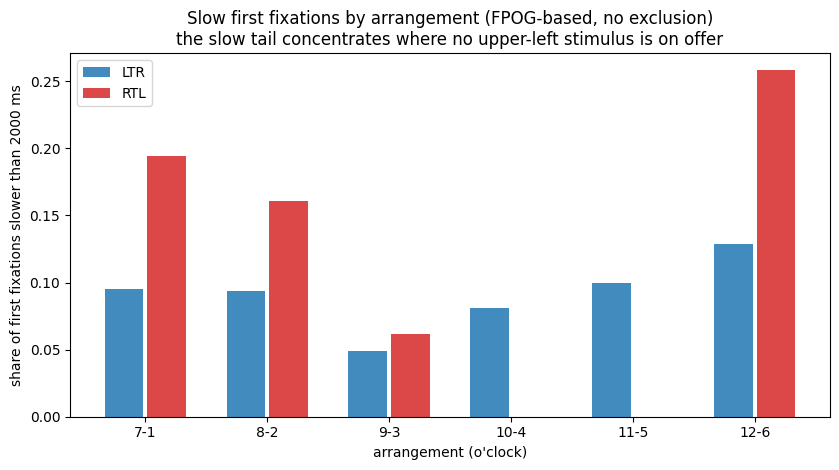

In [12]:
SLOW_MS = 2000  # descriptive fast/slow boundary: the valley of the bimodal latency distribution

lat = df_valid_fpog.dropna(subset=["fpog_first_fix_rt_ms"]).copy()
lat["arrangement_lbl"] = lat["arrangement"].apply(lambda a: f"{a[0]}-{a[1]}")
lat["slow"] = lat["fpog_first_fix_rt_ms"] > SLOW_MS
order = [f"{a}-{b}" for a, b in ARRANGEMENT_ORDER]

med = (lat.groupby(["group", "arrangement_lbl"])["fpog_first_fix_rt_ms"]
       .median().unstack(0).reindex(order).round(0))
pslow = (lat.groupby(["group", "arrangement_lbl"])["slow"]
         .mean().unstack(0).reindex(order).round(3))
summary = pd.concat({"median_ms": med, "p_slow": pslow}, axis=1)
summary.index.name = "arrangement"
summary.to_csv(os.path.join(OUT_DIR, "latency_by_arrangement_fpog.csv"))
print(f"=== first-fixation latency by arrangement x group "
      f"(p_slow = share of trials > {SLOW_MS} ms) ===")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(order))
width = 0.35
for gi, group in enumerate(["LTR", "RTL"]):
    vals = pslow[group].values
    ax.bar(x + (gi - 0.5) * width, vals, width * 0.9,
           color=colors[group], alpha=0.85, label=group)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel("arrangement (o'clock)")
ax.set_ylabel(f"share of first fixations slower than {SLOW_MS} ms")
ax.set_title("Slow first fixations by arrangement (FPOG-based, no exclusion)\n"
             "the slow tail concentrates where no upper-left stimulus is on offer")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "latency_by_arrangement_fpog.png"), dpi=150)
plt.show()

## 9. Summary 

- Both bugs (clock-hour mirroring in Section 3, `first_fix_side` logging in
  Section 6) were confirmed against real data, and the experiment script's
  own "FIX (V8)" comment matches the failure mode seen in 43/44.
- The FPOG recomputation uses the same AOI as the experiment's online
  detection, applied to tracker-classified fixations instead of raw
  samples, with an 80 ms anticipatory-fixation cutoff.
- Group estimates use a hierarchical bootstrap and scale as-is when more
  subjects are added.
- No upper latency cutoff: slow first fixations cluster in arrangements
  without an upper-left stimulus (clearest in RTL for 12-6), so they are
  kept and latency is analyzed as its own outcome.
- Sample so far: 8 LTR / 4 RTL. The RTL group is still small, so treat its
  tighter CIs as 4 subjects who happen to agree, not a settled group effect.
- Tables and plots are saved under `results/`. The exported
  `trials_combined.csv` contains both `fpog_*` (correct, use these) and
  `csvlog_*` (online log, buggy for 43/44) column sets, see Section 7.
- Cells tolerate re-running out of order where that's cheap, but the
  intended workflow is still Run All, top to bottom.